In [1]:
from src.utils import get_data_env
from src.dataloading import EpiConfig, DataOrchestrator, BaseLineDataLoaderManager, DeepDataLoaderManager, GraphDataLoaderManager
from src.models import PersistenceModel, ClimateologyModel, NodeLSTMModel, SeqNodeLSTMModel, NodeGRUModel, GATv2Model, SpatialGNNModel

In [2]:
# get data
disease_name    = 'influenza'
nuts_level      = 'nuts3'
min_date        = '2011-06-01'
max_date        = '2020-06-01'
split_trainval  = '2018-06-01'
split_valtest   = '2019-06-01'
split_berlin    = False

horizon_size    = 1
horizon_leadtime= 3
sequence_length = 3
lag_num         = 1

config = EpiConfig(
    disease             = disease_name,
    data_env_dir        = get_data_env(),
    date_range          = (min_date, max_date),
    horizon_size        = horizon_size,
    sequence_length     = sequence_length,
    horizon_leadtime    = horizon_leadtime,
    lag_num             = lag_num,
    nuts_level          = nuts_level,
    log_transform       = ['incidence'],
    split_berlin        = split_berlin,
    include_population  = True,
    split_trainval      = split_trainval, 
    split_valtest       = split_valtest,
    target_column       = 'incidence',
    lag_column          = 'incidence',  
    verbose             = 0
    )    

data_orchestrator = (DataOrchestrator(config)
                        .load_raw()
                        .harmonize_raw()
                        .process_data()
                        .build_features()
                        .normalize()
                        .finalize()
                        )

In [3]:
deepdataloader = DeepDataLoaderManager(data_orchestrator).construct_dataloaders()
graphloader    = GraphDataLoaderManager(data_orchestrator).retrieve_static_graph('geographical_neighbors1').construct_dataloaders()

In [4]:
n_epochs        = 100
lr              = 0.0001
min_delta       = 0.0001
loss            = 'mse'

global_hparams = {
    "lr"                : lr,
    "n_epochs"          : n_epochs,
    "scheduler"         : 'plateau',
    "scheduler_kwargs"  :  {'mode': 'min', 'factor': 0.5, 'patience': 6},
    'min_delta'         : min_delta,
    'loss'              : loss,
    'patience'          : 20,
    }




==                     gcn                      ==
model_hparams_set ✓
global_hparams_set ✓
Dataloader Snapshot: GraphData(x=(400, 4, 3), y=(400, 1), edge_index=(2, 2488), edge_weight=(2488,))
Epoch 001 train loss: 0.9813, val loss: 2.0393 ✓ (new best)
Epoch 002 train loss: 0.8042, val loss: 1.4632 ✓ (new best)
Epoch 003 train loss: 0.6352, val loss: 1.0359 ✓ (new best)
Epoch 004 train loss: 0.5427, val loss: 0.8550 ✓ (new best)
Epoch 005 train loss: 0.5058, val loss: 0.7861 ✓ (new best)
Epoch 006 train loss: 0.4884, val loss: 0.7459 ✓ (new best)
Epoch 007 train loss: 0.4749, val loss: 0.7154 ✓ (new best)
Epoch 008 train loss: 0.4648, val loss: 0.6868 ✓ (new best)
Epoch 009 train loss: 0.4550, val loss: 0.6601 ✓ (new best)
Epoch 010 train loss: 0.4469, val loss: 0.6359 ✓ (new best)
Epoch 011 train loss: 0.4459, val loss: 0.6141 ✓ (new best)
Epoch 012 train loss: 0.4368, val loss: 0.5940 ✓ (new best)
Epoch 013 train loss: 0.4267, val loss: 0.5726 ✓ (new best)
Epoch 014 train loss: 0.42

/scratch/de-schrijvers/projects/infectious_disease_gnn/src/models/deep/deepmodel.py:248: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


Epoch 100 train loss: 0.3514, val loss: 0.4109 (patience: 16/20)
trained ✓


Forecasting test: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 44/44 [00:00<00:00, 623.21it/s]

Test loss: 0.6695
forecasted ✓


SpatialGNNModel(name='gcn')

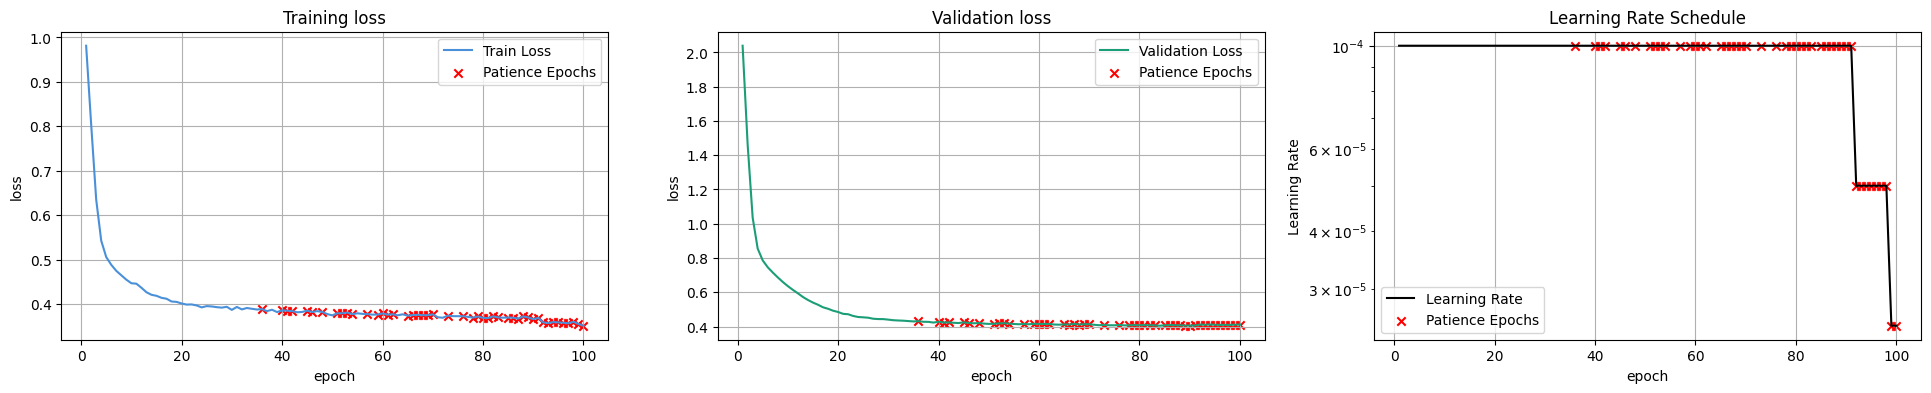

In [5]:
gcn= SpatialGNNModel(graphloader, name = 'gcn', verbose = 10)
gcn.set_model_hparams()
gcn.set_global_hparams(**global_hparams)
gcn.train()
gcn.forecast('test')


==               gatv2_carryover                ==
model_hparams_set ✓
global_hparams_set ✓
Dataloader Snapshot: GraphData(x=(400, 4, 3), y=(400, 1), edge_index=(2, 2488), edge_weight=(2488,))
Epoch 001 train loss: 0.8702, val loss: 1.1831 ✓ (new best)
Epoch 002 train loss: 0.6522, val loss: 0.9260 ✓ (new best)
Epoch 003 train loss: 0.5787, val loss: 0.8043 ✓ (new best)
Epoch 004 train loss: 0.5390, val loss: 0.6925 ✓ (new best)
Epoch 005 train loss: 0.5111, val loss: 0.6249 ✓ (new best)
Epoch 006 train loss: 0.4885, val loss: 0.5731 ✓ (new best)
Epoch 007 train loss: 0.4746, val loss: 0.5485 ✓ (new best)
Epoch 008 train loss: 0.4653, val loss: 0.5308 ✓ (new best)
Epoch 009 train loss: 0.4559, val loss: 0.5059 ✓ (new best)
Epoch 010 train loss: 0.4520, val loss: 0.5015 ✓ (new best)
Epoch 011 train loss: 0.4422, val loss: 0.4723 ✓ (new best)
Epoch 012 train loss: 0.4363, val loss: 0.4671 ✓ (new best)
Epoch 013 train loss: 0.4342, val loss: 0.4527 ✓ (new best)
Epoch 014 train loss: 0.42

/scratch/de-schrijvers/projects/infectious_disease_gnn/src/models/deep/deepmodel.py:248: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


Early stopping: Validation loss hasn't improved for 20 epochs
Restored model from best validation loss: 0.3606
trained ✓


Forecasting test: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 44/44 [00:00<00:00, 559.80it/s]

Test loss: 0.6007
forecasted ✓


GATv2Model(name='gatv2_carryover')

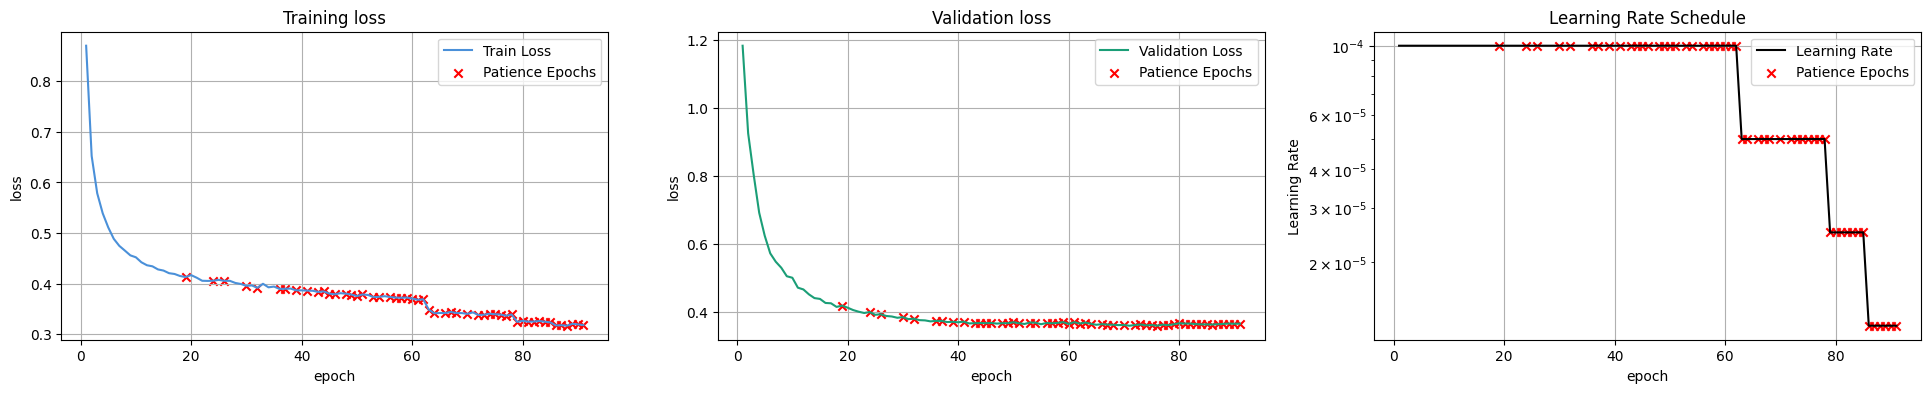

In [6]:
carryover_gatlstm= GATv2Model(graphloader, name = 'gatv2_carryover', verbose = 10)
carryover_gatlstm.set_model_hparams()
carryover_gatlstm.set_global_hparams(**global_hparams)
carryover_gatlstm.train()
carryover_gatlstm.forecast('test')


==                gru_carryover                 ==
model_hparams_set ✓
global_hparams_set ✓
Dataloader Snapshot: DeepData(x=(400, 4, 3), y=(400, 1))
Epoch 001 train loss: 0.7096, val loss: 0.8760 ✓ (new best)
Epoch 002 train loss: 0.5632, val loss: 0.8099 ✓ (new best)
Epoch 003 train loss: 0.5382, val loss: 0.7704 ✓ (new best)
Epoch 004 train loss: 0.5188, val loss: 0.7303 ✓ (new best)
Epoch 005 train loss: 0.5012, val loss: 0.6945 ✓ (new best)
Epoch 006 train loss: 0.4840, val loss: 0.6607 ✓ (new best)
Epoch 007 train loss: 0.4711, val loss: 0.6278 ✓ (new best)
Epoch 008 train loss: 0.4564, val loss: 0.6016 ✓ (new best)
Epoch 009 train loss: 0.4463, val loss: 0.5785 ✓ (new best)
Epoch 010 train loss: 0.4415, val loss: 0.5615 ✓ (new best)
Epoch 011 train loss: 0.4377, val loss: 0.5425 ✓ (new best)
Epoch 012 train loss: 0.4302, val loss: 0.5284 ✓ (new best)
Epoch 013 train loss: 0.4253, val loss: 0.5142 ✓ (new best)
Epoch 014 train loss: 0.4245, val loss: 0.4991 ✓ (new best)
Epoch 015 

/scratch/de-schrijvers/projects/infectious_disease_gnn/src/models/deep/deepmodel.py:248: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


Early stopping: Validation loss hasn't improved for 20 epochs
Restored model from best validation loss: 0.3415
trained ✓


Forecasting test: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 44/44 [00:00<00:00, 1377.95it/s]

Test loss: 0.5886
forecasted ✓


NodeGRUModel(name='gru_carryover')

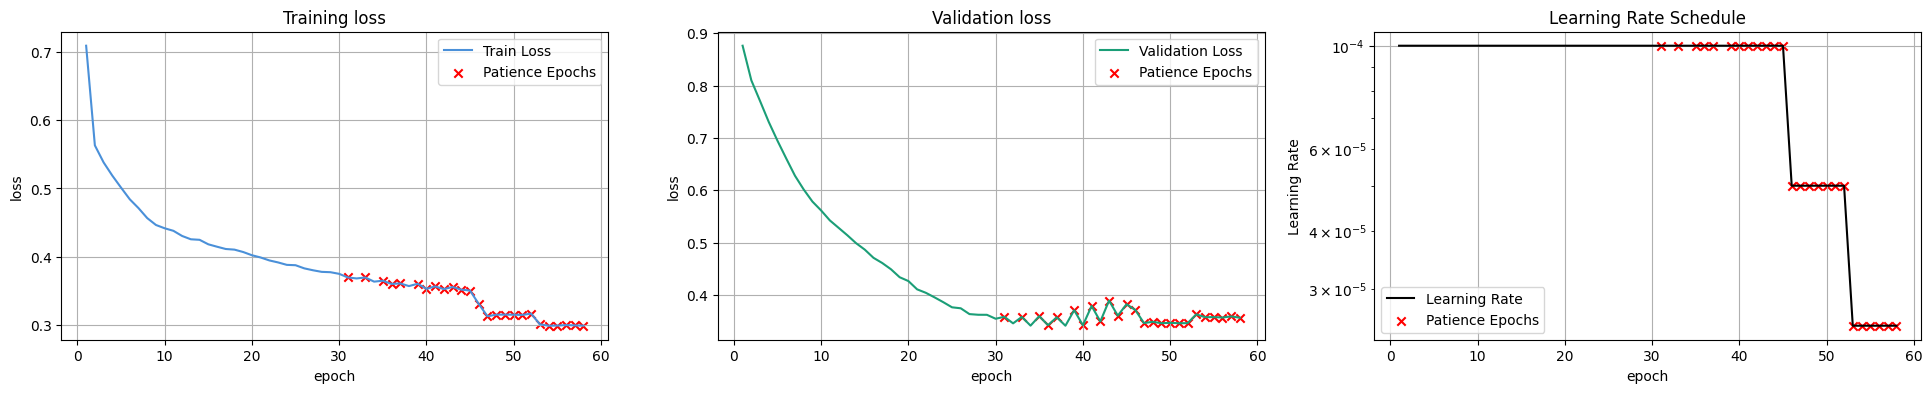

In [7]:
carryover_gru= NodeGRUModel(deepdataloader, name = 'gru_carryover', verbose = 10)
carryover_gru.set_model_hparams()
carryover_gru.set_global_hparams(**global_hparams)
carryover_gru.train()
carryover_gru.forecast('test')


==                lstm_carryover                ==
model_hparams_set ✓
global_hparams_set ✓
Dataloader Snapshot: DeepData(x=(400, 4, 3), y=(400, 1))
Epoch 001 train loss: 0.7979, val loss: 0.9599 ✓ (new best)
Epoch 002 train loss: 0.6056, val loss: 0.8564 ✓ (new best)
Epoch 003 train loss: 0.5729, val loss: 0.8036 ✓ (new best)
Epoch 004 train loss: 0.5580, val loss: 0.7606 ✓ (new best)
Epoch 005 train loss: 0.5455, val loss: 0.7201 ✓ (new best)
Epoch 006 train loss: 0.5339, val loss: 0.6826 ✓ (new best)
Epoch 007 train loss: 0.5238, val loss: 0.6475 ✓ (new best)
Epoch 008 train loss: 0.5132, val loss: 0.6144 ✓ (new best)
Epoch 009 train loss: 0.5044, val loss: 0.5776 ✓ (new best)
Epoch 010 train loss: 0.4985, val loss: 0.5626 ✓ (new best)
Epoch 011 train loss: 0.4837, val loss: 0.5101 ✓ (new best)
Epoch 012 train loss: 0.4811, val loss: 0.5200 (patience: 1/20)
Epoch 013 train loss: 0.4604, val loss: 0.4559 ✓ (new best)
Epoch 014 train loss: 0.4639, val loss: 0.4794 (patience: 1/20)
Ep

/scratch/de-schrijvers/projects/infectious_disease_gnn/src/models/deep/deepmodel.py:248: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


Early stopping: Validation loss hasn't improved for 20 epochs
Restored model from best validation loss: 0.3467
trained ✓


Forecasting test: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 44/44 [00:00<00:00, 566.94it/s]

Test loss: 0.5991
forecasted ✓


NodeLSTMModel(name='lstm_carryover')

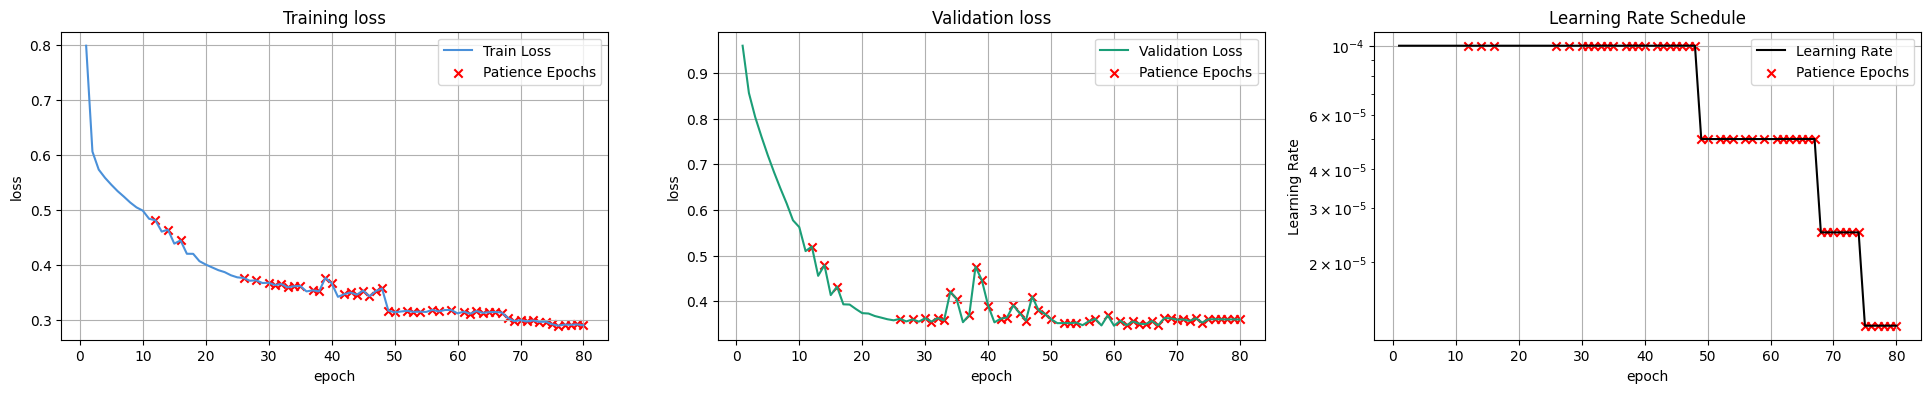

In [8]:
carryover_lstm= NodeLSTMModel(deepdataloader, name = 'lstm_carryover', verbose = 10)
carryover_lstm.set_model_hparams()
carryover_lstm.set_global_hparams(**global_hparams)
carryover_lstm.train()
carryover_lstm.forecast('test')


==                   lstm_seq                   ==
model_hparams_set ✓
global_hparams_set ✓
Dataloader Snapshot: DeepData(x=(400, 4, 3), y=(400, 1))
Epoch 001 train loss: 0.8394, val loss: 1.4037 ✓ (new best)
Epoch 002 train loss: 0.6619, val loss: 1.1895 ✓ (new best)
Epoch 003 train loss: 0.6430, val loss: 1.1491 ✓ (new best)
Epoch 004 train loss: 0.6277, val loss: 1.1115 ✓ (new best)
Epoch 005 train loss: 0.6130, val loss: 1.0690 ✓ (new best)
Epoch 006 train loss: 0.5973, val loss: 1.0182 ✓ (new best)
Epoch 007 train loss: 0.5793, val loss: 0.9555 ✓ (new best)
Epoch 008 train loss: 0.5583, val loss: 0.8789 ✓ (new best)
Epoch 009 train loss: 0.5343, val loss: 0.7896 ✓ (new best)
Epoch 010 train loss: 0.5091, val loss: 0.6974 ✓ (new best)
Epoch 011 train loss: 0.4865, val loss: 0.6251 ✓ (new best)
Epoch 012 train loss: 0.4697, val loss: 0.5877 ✓ (new best)
Epoch 013 train loss: 0.4573, val loss: 0.5677 ✓ (new best)
Epoch 014 train loss: 0.4462, val loss: 0.5484 ✓ (new best)
Epoch 015 

/scratch/de-schrijvers/projects/infectious_disease_gnn/src/models/deep/deepmodel.py:248: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


Early stopping: Validation loss hasn't improved for 20 epochs
Restored model from best validation loss: 0.3485
trained ✓


Forecasting test: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 44/44 [00:00<00:00, 2233.31it/s]

Test loss: 0.6650
forecasted ✓


SeqNodeLSTMModel(name='lstm_seq')

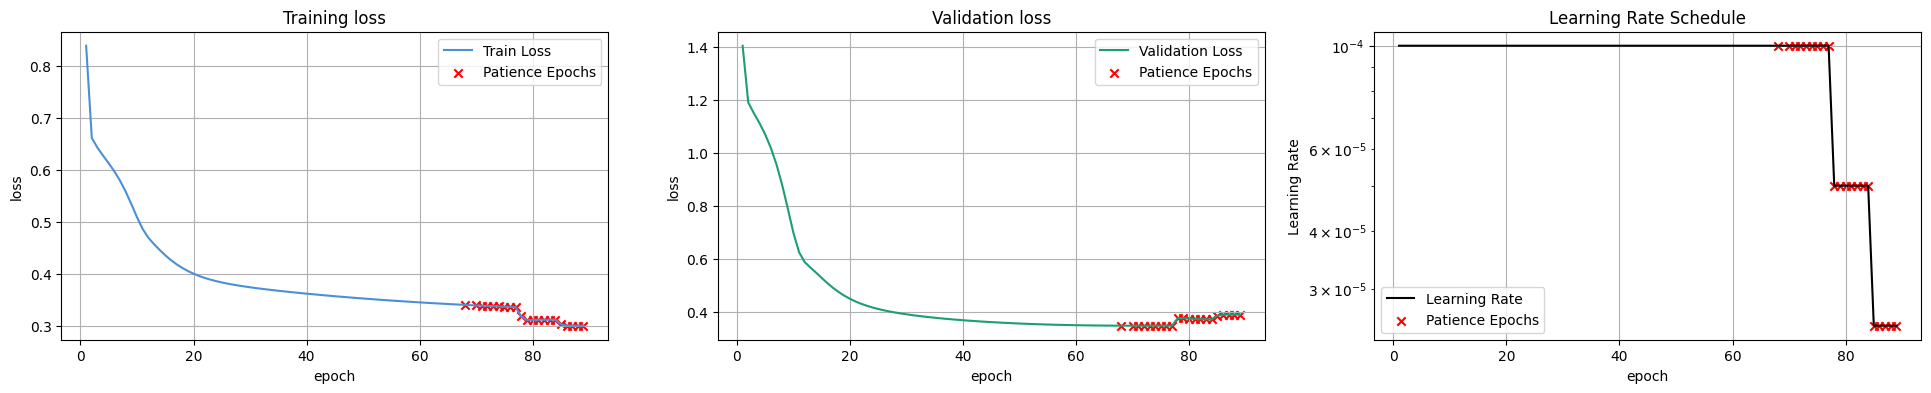

In [9]:
sequentialized_lstm= SeqNodeLSTMModel(deepdataloader, name = 'lstm_seq', verbose = 10)
sequentialized_lstm.set_model_hparams()
sequentialized_lstm.set_global_hparams(**global_hparams)
sequentialized_lstm.train()
sequentialized_lstm.forecast('test')

In [10]:
dl = BaseLineDataLoaderManager(data_orchestrator)
ps = PersistenceModel(dl)
cm = ClimateologyModel(dl)


ps.forecast('train')
ps.forecast('val')
ps.forecast('test')
raw_f1 = ps.show_forecasts([1], 'test')

cm.forecast('test')
raw_f2 = cm.show_forecasts([1], 'test')


==             static_commuter24_2              ==
model_hparams_set ✓
global_hparams_set ✓
Dataloader Snapshot: GraphData(x=(400, 4, 3), y=(400, 1), edge_index=(2, 2685), edge_weight=(2685,))
Epoch 001 train loss: 0.8466, val loss: 1.1516 ✓ (new best)
Epoch 002 train loss: 0.6675, val loss: 0.9278 ✓ (new best)
Epoch 003 train loss: 0.5960, val loss: 0.8497 ✓ (new best)
Epoch 004 train loss: 0.5518, val loss: 0.6958 ✓ (new best)
Epoch 005 train loss: 0.5209, val loss: 0.6799 ✓ (new best)
Epoch 006 train loss: 0.5068, val loss: 0.6137 ✓ (new best)
Epoch 007 train loss: 0.4895, val loss: 0.5957 ✓ (new best)
Epoch 008 train loss: 0.4813, val loss: 0.5570 ✓ (new best)
Epoch 009 train loss: 0.4657, val loss: 0.5615 (patience: 1/20)
Epoch 010 train loss: 0.4625, val loss: 0.5165 ✓ (new best)
Epoch 011 train loss: 0.4533, val loss: 0.5150 ✓ (new best)
Epoch 012 train loss: 0.4505, val loss: 0.4850 ✓ (new best)
Epoch 013 train loss: 0.4407, val loss: 0.4771 ✓ (new best)
Epoch 014 train loss: 

/scratch/de-schrijvers/projects/infectious_disease_gnn/src/models/deep/deepmodel.py:248: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


Early stopping: Validation loss hasn't improved for 20 epochs
Restored model from best validation loss: 0.3646
trained ✓


Forecasting test: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 44/44 [00:00<00:00, 566.76it/s]

Test loss: 0.6148
forecasted ✓


GATv2Model(name='static_commuter24_2')

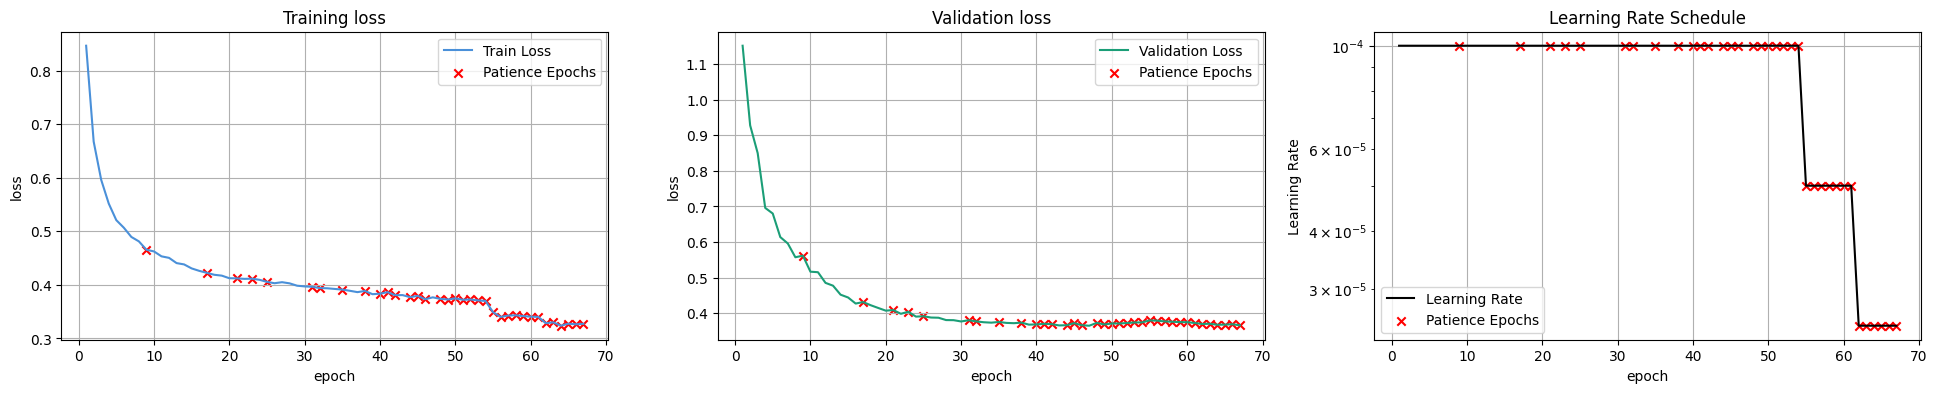

In [13]:
graphloader2   = GraphDataLoaderManager(data_orchestrator).retrieve_static_graph('static_commuter24_2').construct_dataloaders()
carryover_gatlstm2= GATv2Model(graphloader2, name = 'static_commuter24_2', verbose = 10)
carryover_gatlstm2.set_model_hparams()
carryover_gatlstm2.set_global_hparams(**global_hparams)
carryover_gatlstm2.train()
carryover_gatlstm2.forecast('test')

computing metrics:   0%|                                                                                                                                                                | 0/6 [00:00<?, ?it/s]

computing metrics: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [00:06<00:00,  1.14s/it]
/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/evaluationplotter.py:215: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center', fontsize=8)
/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/evaluationplotter.py:215: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center', fontsize=8)
/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/evaluationplotter.py:215: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. af

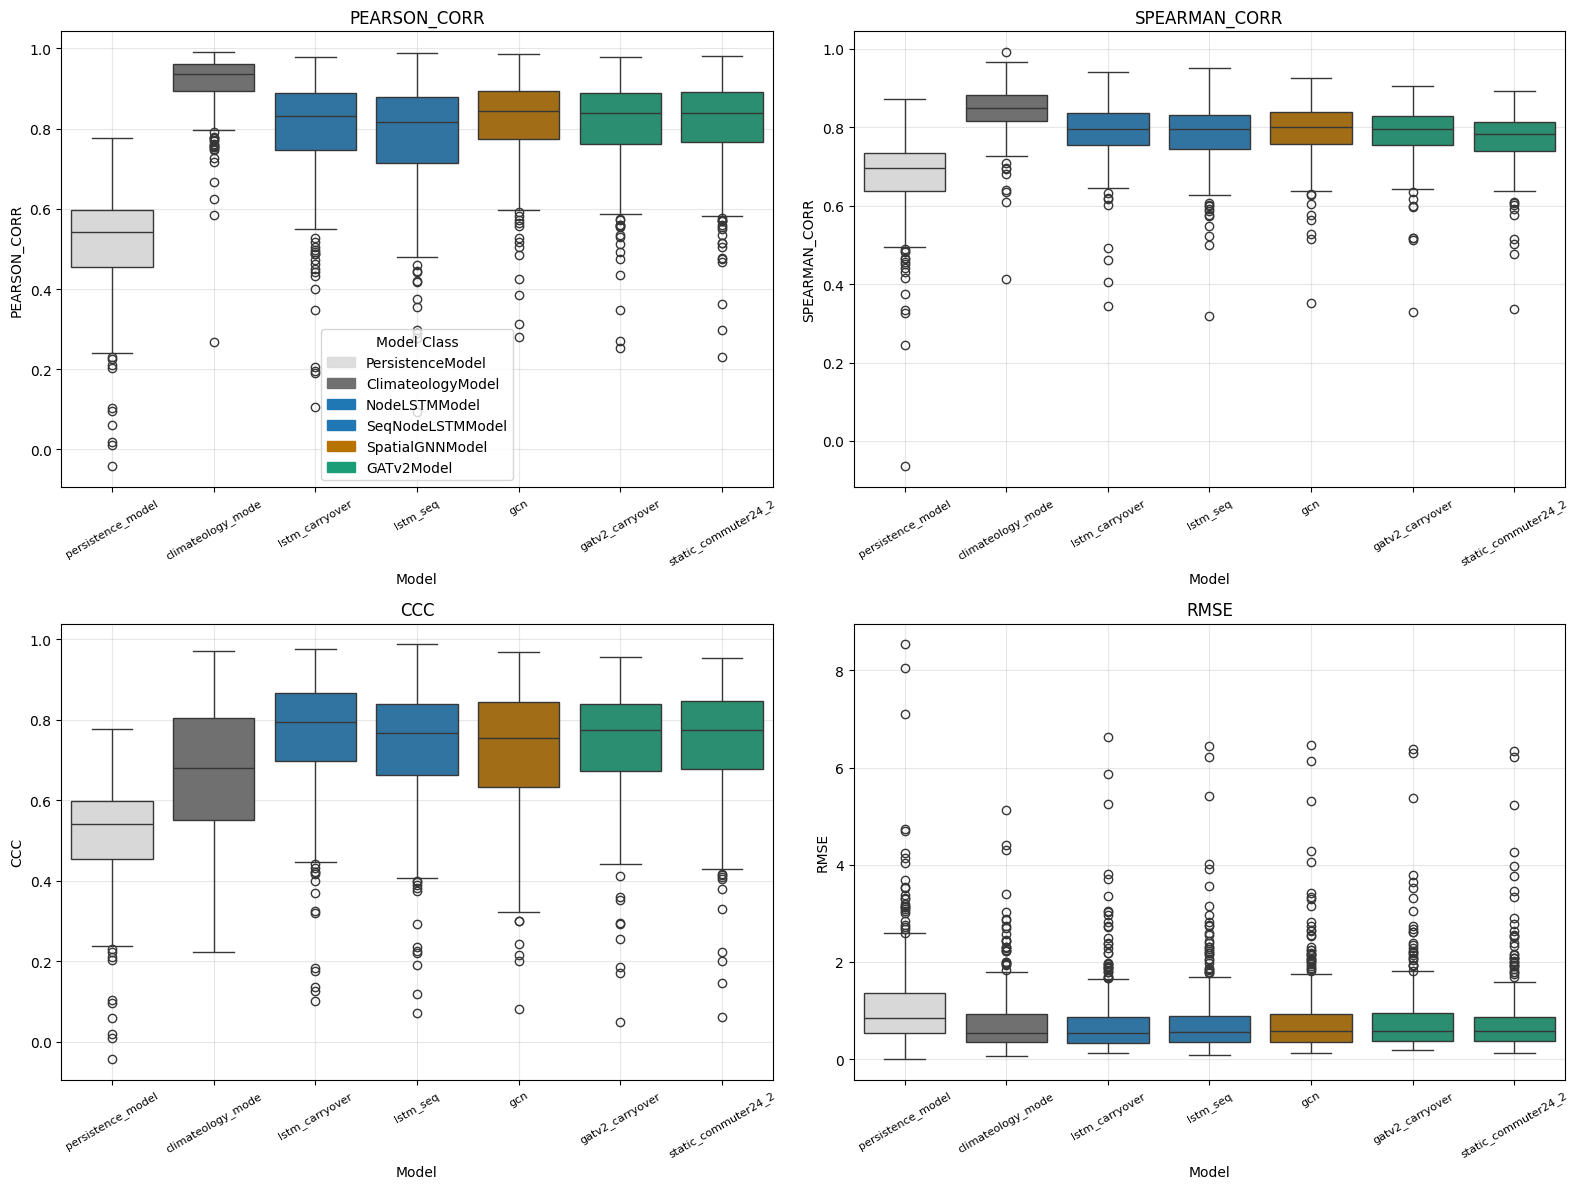

In [15]:
from src.evaluation import Evaluator

e = Evaluator([ps, cm, carryover_lstm, sequentialized_lstm, gcn,  carryover_gatlstm, carryover_gatlstm2]).add_evaluation()
e.plotter.plot_metric_compilation(plot_types=['box','box','box','box']).show()

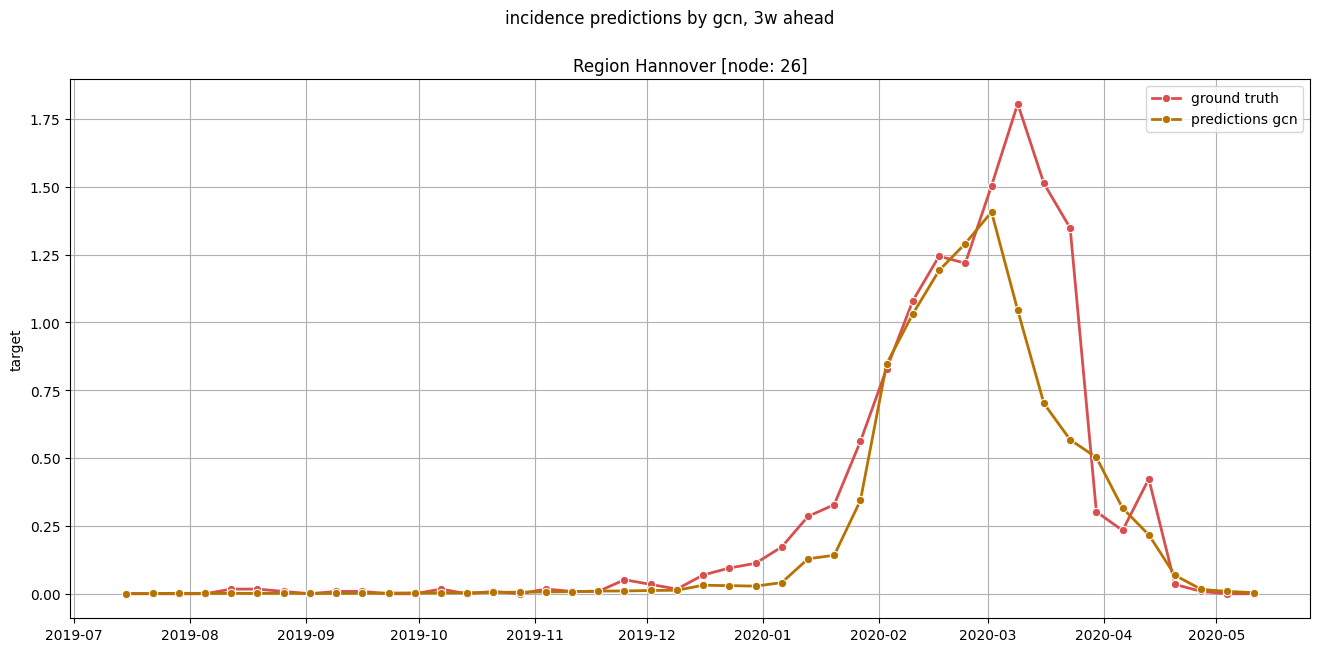

In [ ]:
carryover_gatlstm.show_forecasts(26).show()